# Real Data Analysis: KRT8 x KRT18 co-localisation
- Looking at strips 2 + 3, FOV 3

In [ ]:
%run 03_K_function.ipynb

## Set up:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import time

fov3 = pd.read_parquet("../data/processed/fov3_strips.parquet")

GENE_A = 'KRT8'
GENE_B = 'KRT18'
R_MAX = 250          # px - conservative: narrowest strip dim is ~1200px, so < 1200/4 = 300
N_R = 50             # number of radii to evaluate (smooth enough, not excessive)
N_SIM = 99           # 99 sims -> pointwise alpha ~0.02; use 999 for publication
SEED = 42

r_vals = np.linspace(0, R_MAX, N_R)

### Run analysis on both strips
Store results in a dict so the plotting code is clean and extensible
to more strips / gene pairs later.

In [ ]:
results = {}

for strip_name in ['strip_2', 'strip_3']:
    print(f"\n{'='*60}")
    print(f"  Processing {strip_name}")
    print(f"{'='*60}")
    
    strip_df = fov3[fov3['strip'] == strip_name]
    
    coords_a = get_coords(strip_df, GENE_A)
    coords_b = get_coords(strip_df, GENE_B)
    window   = get_window(strip_df)
    
    if DIAGNOSTICS:
    plot_diagnostics(coords_a, coords_b, window,
                     gene_a=GENE_A, gene_b=GENE_B,
                     title=f'{GENE_A} × {GENE_B} | {strip_name}')
    plt.show()

    n_a, n_b = len(coords_a), len(coords_b)
    narrow_dim = min(window[1] - window[0], window[3] - window[2])
    
    print(f"  {GENE_A}: {n_a} transcripts")
    print(f"  {GENE_B}: {n_b} transcripts")
    print(f"  Window: x=[{window[0]:.0f}, {window[1]:.0f}], "
          f"y=[{window[2]:.0f}, {window[3]:.0f}]")
    print(f"  Narrowest dimension: {narrow_dim:.0f} px")
    print(f"  R_MAX = {R_MAX} px ({R_MAX/narrow_dim*100:.0f}% of narrow dim)")
    
    # --- Observed L(r) ---
    t0 = time.time()
    k_obs = bivariate_k(coords_a, coords_b, r_vals, window)
    l_obs = k_to_l(k_obs, r_vals)
    t_obs = time.time() - t0
    print(f"  Observed L(r) computed in {t_obs:.1f}s")
    
    # Spot-check
    for r_check in [50, 100, 200]:
        idx = np.argmin(np.abs(r_vals - r_check))
        print(f"    L(r={r_check}): {l_obs[idx]:.2f}")
    
    # --- Permutation envelope ---
    print(f"  Computing {N_SIM}-simulation envelope (this will take ~{t_obs * N_SIM:.0f}s)...")
    t0 = time.time()
    l_lo, l_hi = compute_envelope(coords_a, coords_b, r_vals, window,
                                   n_sim=N_SIM, seed=SEED)
    t_env = time.time() - t0
    print(f"  Envelope computed in {t_env:.1f}s")
    
    # Store everything
    results[strip_name] = {
        'coords_a': coords_a,
        'coords_b': coords_b,
        'window': window,
        'k_obs': k_obs,
        'l_obs': l_obs,
        'l_lo': l_lo,
        'l_hi': l_hi,
        'n_a': n_a,
        'n_b': n_b,
    }


  Processing strip_2
  KRT8: 74 transcripts
  KRT18: 118 transcripts
  Window: x=[13052, 14252], y=[34219, 38450]
  Narrowest dimension: 1200 px
  R_MAX = 250 px (21% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 130.99
    L(r=100): 180.74
    L(r=200): 225.04
  Computing 99-simulation envelope (this will take ~1s)...
  Envelope computed in 1.0s

  Processing strip_3
  KRT8: 70 transcripts
  KRT18: 103 transcripts
  Window: x=[14254, 15605], y=[34219, 38448]
  Narrowest dimension: 1351 px
  R_MAX = 250 px (19% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 158.14
    L(r=100): 194.04
    L(r=200): 212.89
  Computing 99-simulation envelope (this will take ~1s)...
  Envelope computed in 0.8s


### Individual L-function plots with envelopes
One plot per strip showing: observed L(r), permutation envelope, CSR baseline

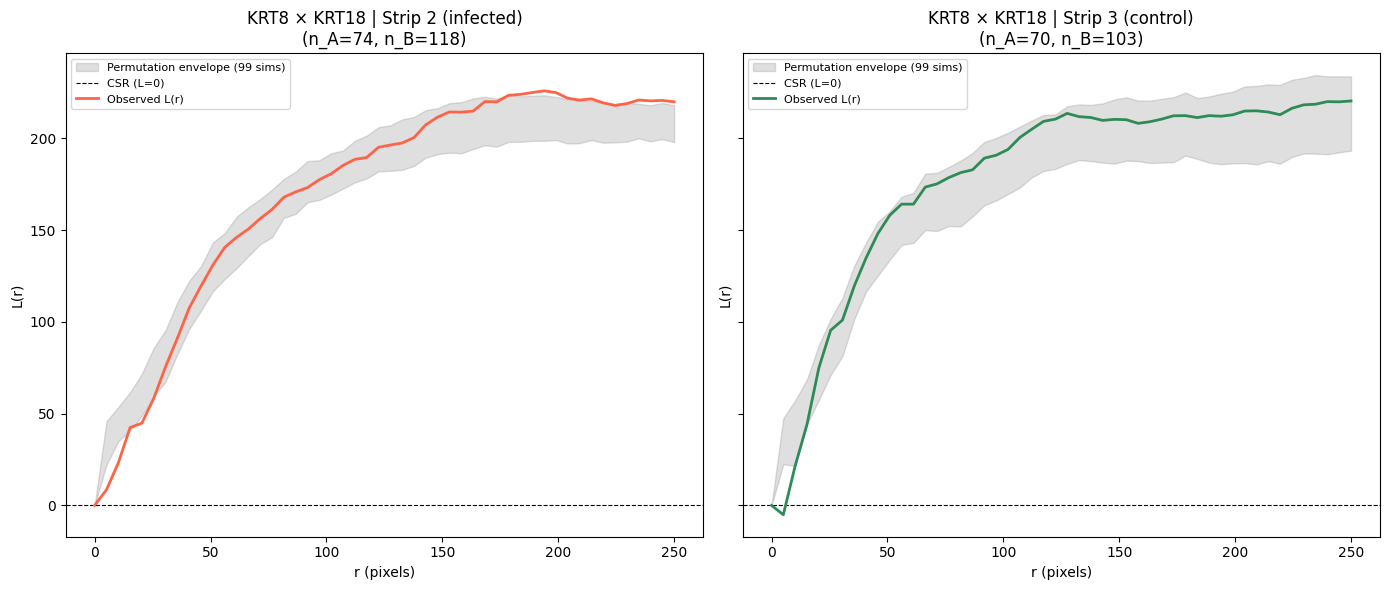

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

strip_labels = {
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
strip_colors = {
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

for ax, strip_name in zip(axes, ['strip_2', 'strip_3']):
    res = results[strip_name]
    
    # Envelope (shaded region = range of null simulations)
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
    
    # CSR baseline
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
    
    # Observed
    ax.plot(r_vals, res['l_obs'], color=strip_colors[strip_name],
            linewidth=2, label=f'Observed L(r)')
    
    ax.set_xlabel('r (pixels)')
    ax.set_ylabel('L(r)')
    ax.set_title(f"{GENE_A} × {GENE_B} | {strip_labels[strip_name]}\n"
                 f"(n_A={res['n_a']}, n_B={res['n_b']})")
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/04_Lfunction_KRT8_KRT18_by_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Overlay comparison: infected vs control on same axes
This is the key comparison plot - does co-localisation differ by condition?

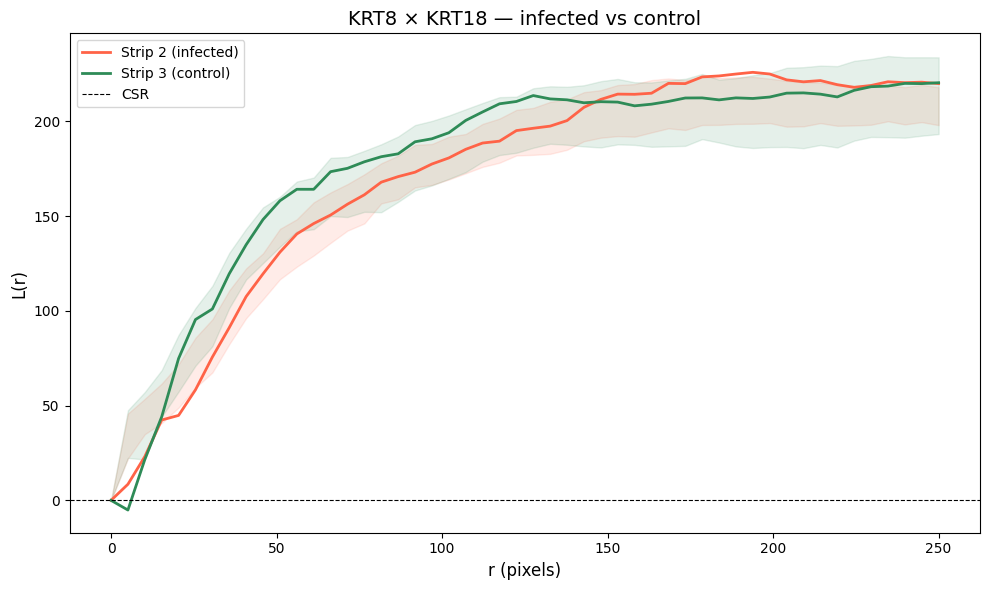

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for strip_name in ['strip_2', 'strip_3']:
    res = results[strip_name]
    color = strip_colors[strip_name]
    label = strip_labels[strip_name]
    
    # Envelope as shaded band
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.12, color=color)
    
    # Observed curve
    ax.plot(r_vals, res['l_obs'], color=color, linewidth=2, label=label)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR')
ax.set_xlabel('r (pixels)', fontsize=12)
ax.set_ylabel('L(r)', fontsize=12)
ax.set_title(f'{GENE_A} × {GENE_B} — infected vs control', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/04_Lfunction_KRT8_KRT18_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Spatial scatter plots of the gene pair in each strip
Visual sanity check: do the transcript locations look co-localised?

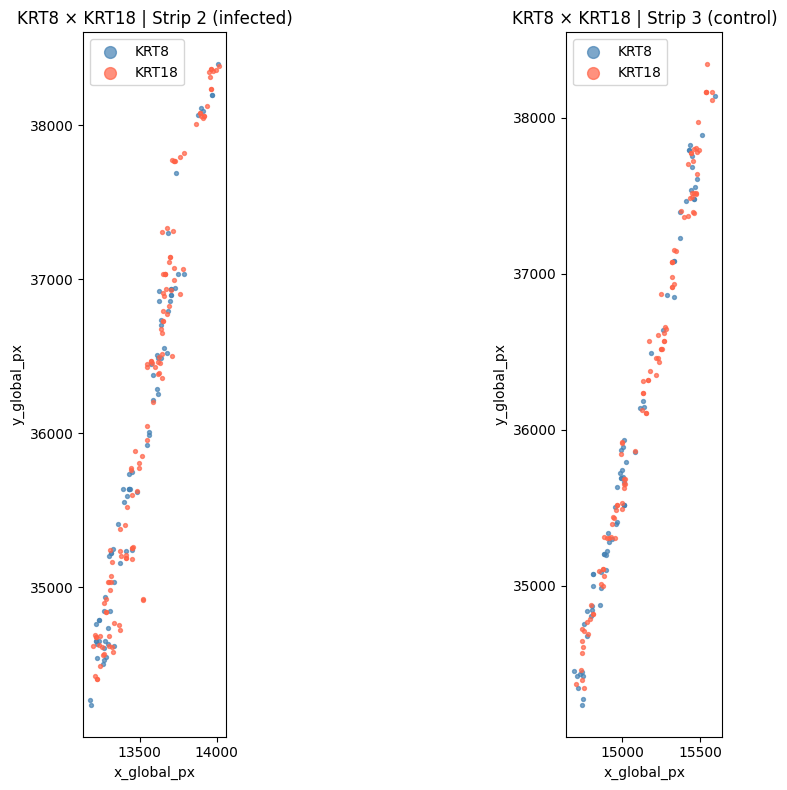

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for ax, strip_name in zip(axes, ['strip_2', 'strip_3']):
    res = results[strip_name]
    
    ax.scatter(res['coords_a'][:, 0], res['coords_a'][:, 1],
               s=8, alpha=0.7, color='steelblue', label=GENE_A)
    ax.scatter(res['coords_b'][:, 0], res['coords_b'][:, 1],
               s=8, alpha=0.7, color='tomato', label=GENE_B)
    
    ax.set_xlabel('x_global_px')
    ax.set_ylabel('y_global_px')
    ax.set_title(f'{GENE_A} × {GENE_B} | {strip_labels[strip_name]}')
    ax.legend(markerscale=3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../results/figures/04_scatter_KRT8_KRT18_by_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Quantitative summary
Print a table of key metrics for the lab notebook

In [7]:
print(f"\n{'='*70}")
print(f"  SUMMARY: {GENE_A} × {GENE_B} co-localisation")
print(f"  R_MAX = {R_MAX} px | N_SIM = {N_SIM} | seed = {SEED}")
print(f"{'='*70}\n")

header = f"{'Strip':<20} {'n_A':>5} {'n_B':>5} {'L(50)':>8} {'L(100)':>8} {'L(200)':>8} {'Above env?':>12}"
print(header)
print('-' * len(header))

for strip_name in ['strip_2', 'strip_3']:
    res = results[strip_name]
    
    l50  = res['l_obs'][np.argmin(np.abs(r_vals - 50))]
    l100 = res['l_obs'][np.argmin(np.abs(r_vals - 100))]
    l200 = res['l_obs'][np.argmin(np.abs(r_vals - 200))]
    
    # Check if observed exceeds the upper envelope at any r > 0
    # (excluding r=0 where everything is trivially 0)
    above = np.any(res['l_obs'][1:] > res['l_hi'][1:])
    
    print(f"{strip_labels[strip_name]:<20} {res['n_a']:>5} {res['n_b']:>5} "
          f"{l50:>8.2f} {l100:>8.2f} {l200:>8.2f} {'YES' if above else 'no':>12}")

print(f"\nInterpretation:")
print(f"  L(r) > 0 at scale r => {GENE_A} and {GENE_B} transcripts are")
print(f"  more co-localised than expected under spatial independence.")
print(f"  'Above env?' = observed L(r) exceeds ALL {N_SIM} permutation")
print(f"  simulations at some r => significant at pointwise alpha ~{1/(N_SIM+1):.3f}.")


  SUMMARY: KRT8 × KRT18 co-localisation
  R_MAX = 250 px | N_SIM = 99 | seed = 42

Strip                  n_A   n_B    L(50)   L(100)   L(200)   Above env?
------------------------------------------------------------------------
Strip 2 (infected)      74   118   130.99   180.74   225.04          YES
Strip 3 (control)       70   103   158.14   194.04   212.89           no

Interpretation:
  L(r) > 0 at scale r => KRT8 and KRT18 transcripts are
  more co-localised than expected under spatial independence.
  'Above env?' = observed L(r) exceeds ALL 99 permutation
  simulations at some r => significant at pointwise alpha ~0.010.


### Analysis:
- Successful positive control
- Both strips show strong positive L(r)
    - Massively above CSR which makes sense given that KRT8 and KRT18 are obligate heterodimer partners expressed in the same cells

- Envelope comparison:
    - Strip_2 (infected) shows the observed cirve poking out above the envelope at some scales
    - Strip_3 (control) does not
    But looking at the plot carefully: both observed curves are similar in magnitude, and both sit well above zero. The difference in the "Above env?" column is not because strip_3 has weaker co-localisation, it's because the envelope is wider for strip_3.
    
     The permutation null pools all KRT8 + KRT18 transcripts and randomly relabels them. If the transcripts are already spatially clustered (which they are - they come from cells), then even after relabelling, the two random subsets will tend to co-localise because they're drawn from the same clustered pool. The envelope captures this: it tells us how much co-localisation we'd expect just from the fact that both genes share the same spatial distribution, regardless of any gene-specific association.

     First, the L(r) magnitudes (100–225) are interpretable. L(r) = 130 at r=50 means the effective radius at which you'd observe the measured density of B-around-A is about 180px (since L(r) = √(K/π) - r, so √(K/π) ≈ 180), versus the 50px you'd expect under CSR. In practical terms: KRT18 transcripts are roughly 3–4× more concentrated near KRT8 transcripts than a uniform distribution would predict.

     Second, the two curves are remarkably similar in shape. Both rise steeply to ~50px (roughly cell-scale co-localisation), then flatten. This plateau shape makes sense - once r exceeds the cell diameter, you're mostly adding empty space, and the cumulative function grows more slowly.